
---

**1. Question:** What fundamental problem in Deep Neural Networks (DNNs) does the Encoder-Decoder architecture address?

*   **Answer:** DNNs traditionally struggle to **map sequences to sequences** where the **input and output lengths are not fixed in advance**, a significant limitation for tasks like machine translation, speech recognition, or question answering.

---

**2. Question:** What is the core architectural concept of the Encoder-Decoder model for sequence-to-sequence learning?

*   **Answer:** It uses **two deep Long Short-Term Memory (LSTM) networks**: one **Encoder LSTM** to read the input sequence (token by token) and transform it into a **fixed-dimensional vector representation** (known as the **context vector**), and another **Decoder LSTM** to generate the target sequence from this context vector.

---

**3. Question:** Why were Long Short-Term Memory (LSTM) networks specifically chosen as the primary building blocks for both the Encoder and Decoder?

*   **Answer:** LSTMs were selected due to their proven ability to successfully learn on data with **long-range temporal dependencies**. This capability is critical because sequence-to-sequence tasks often involve a considerable time lag between related words in the input and their corresponding outputs.

---

**4. Question:** What crucial data transformation was found to significantly improve the LSTM's performance, and what was the reasoning behind it?

*   **Answer:** **Reversing the order of words in all input (source) sentences** (but not the target sentences). This simple trick **markedly improved performance** because it introduced **many short-term dependencies** between the source and target words, which reduced the "minimal time lag" and made the optimization problem easier for Stochastic Gradient Descent (SGD).

---

**5. Question:** What was the main machine translation task and dataset used to evaluate the Encoder-Decoder architecture in the original paper?

*   **Answer:** The primary evaluation was on the **WMT'14 English to French machine translation task**. The models were trained on a subset of approximately **12 million sentences**, comprising 348 million French words and 304 million English words.

---

**6. Question:** How did the Encoder-Decoder LSTM system's direct translation performance compare to the baseline Statistical Machine Translation (SMT) system on the WMT'14 task?

*   **Answer:** An ensemble of 5 deep LSTMs achieved a **BLEU score of 34.81** on the WMT'14 English to French test set, which **outperformed** the phrase-based SMT baseline system's score of **33.30**.

---

**7. Question:** How did the Encoder-Decoder system perform on very long sentences, a common challenge for neural sequence models at the time?

*   **Answer:** Surprisingly, the LSTM **did not suffer on very long sentences**. LSTMs trained on **reversed source sentences** showed better memory utilization and could translate long sentences effectively, contradicting findings from other researchers with related architectures.

---

**8. Question:** What role do "embeddings" play in the Encoder-Decoder architecture, and why are they preferred over one-hot encoding for word representation?

*   **Answer:** **Word embeddings** are used to provide **low-dimensional, dense vector representations** of words. They are preferred over high-dimensional, sparse one-hot encodings because they are much more **efficient** (especially with large vocabularies), can **capture semantic meaning** and context, and lead to better generalization.

---

**9. Question:** What is "Teacher Forcing" and how is it applied during the training process of the decoder?

*   **Answer:** **Teacher Forcing** is a training technique used in the decoder where, at each time step, the **correct (ground truth) output word from the training data** is fed as the input for the subsequent time step, instead of using the decoder's own predicted word. This approach **accelerates training convergence** and helps the model learn faster.

---

**10. Question:** Beyond a single layer, what architectural enhancement was incorporated into the LSTMs for the Encoder and Decoder, and what were its benefits?

*   **Answer:** **Deep LSTMs** (multi-layered LSTMs, specifically **four layers** in the original paper) were used. This enhancement offered several benefits:
    *   Improved handling of **long-term dependencies** for longer sentences or paragraphs.
    *   Enabled **layered (hierarchical) representation learning**, where lower layers capture word-level features and higher layers capture sentence or paragraph-level context.
    *   Increased the model's **learning capacity** and **generalization ability** due to a higher number of parameters.

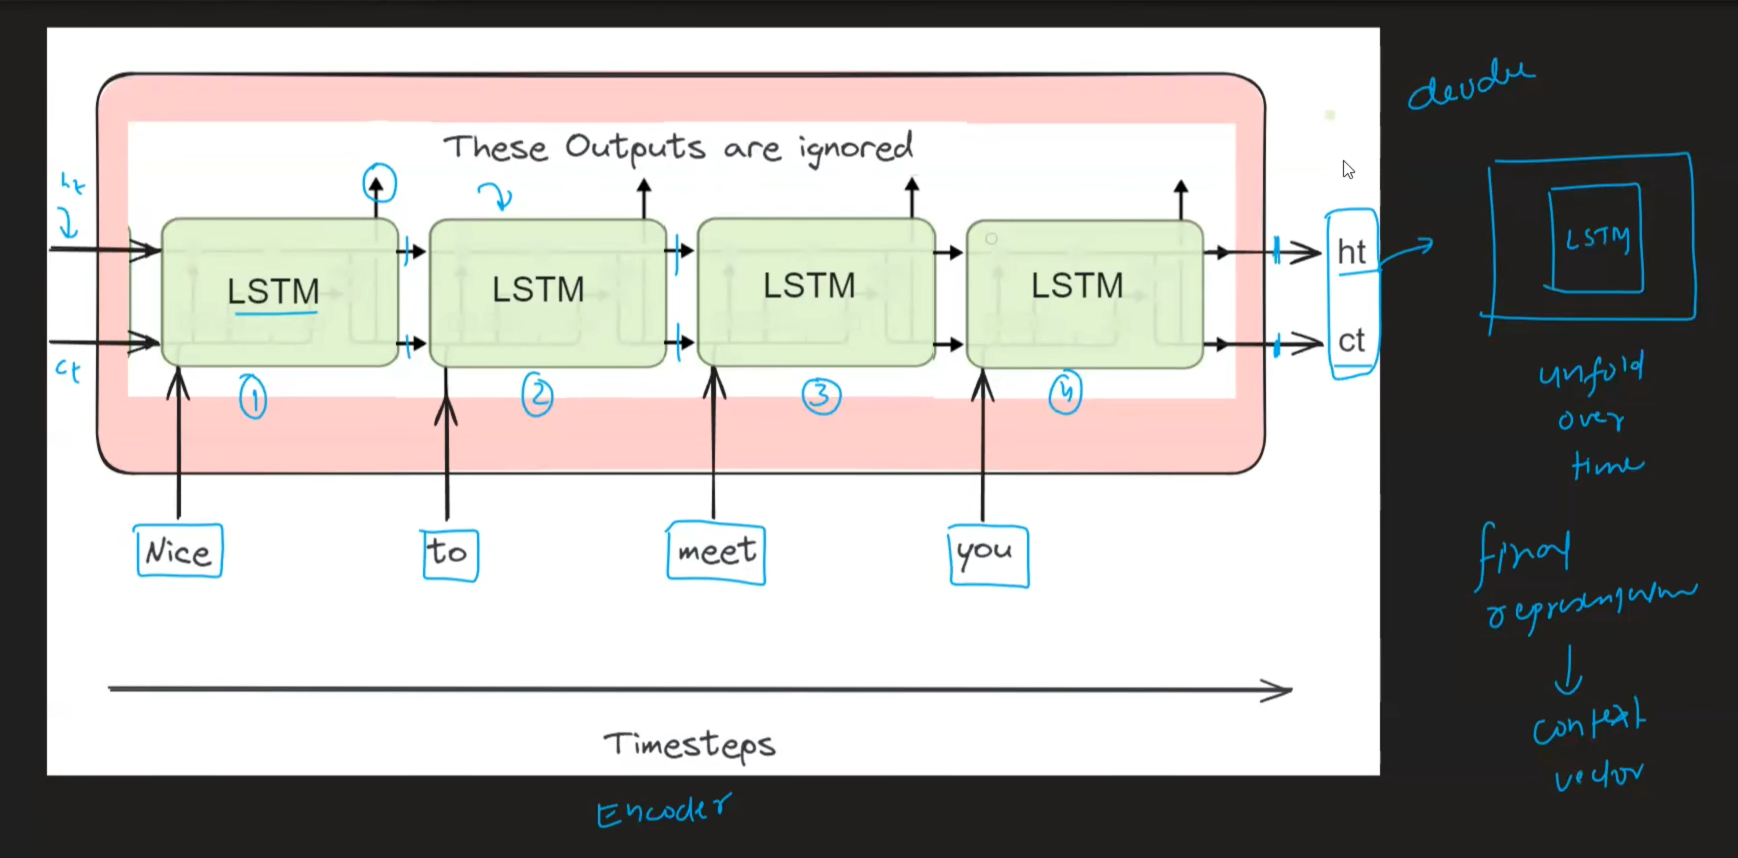

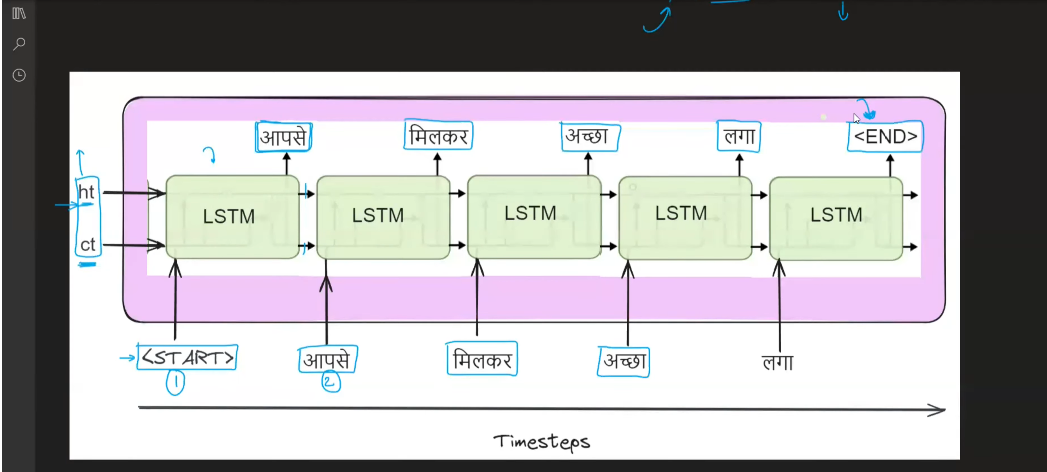

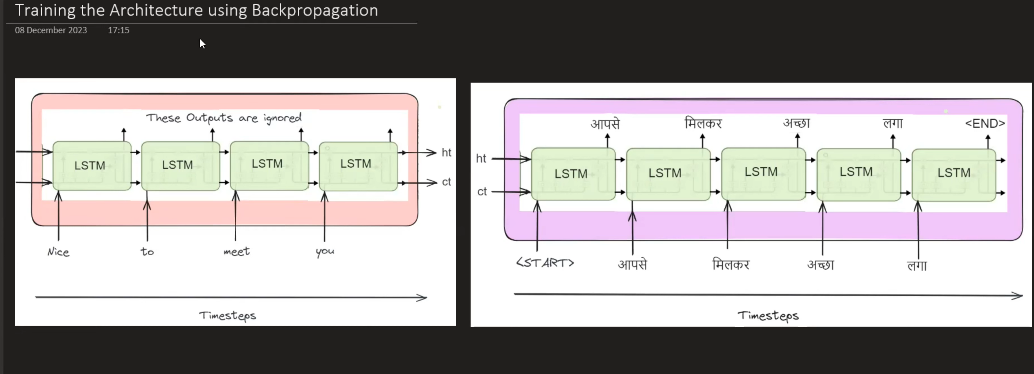

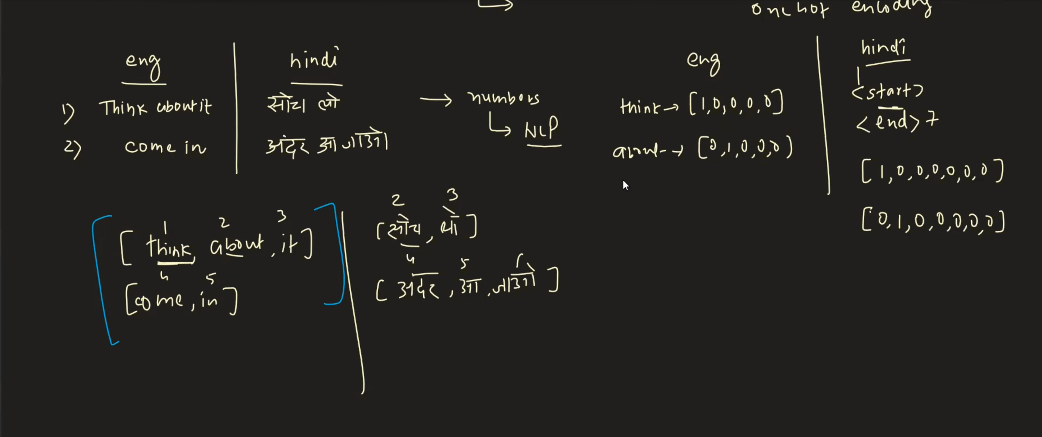

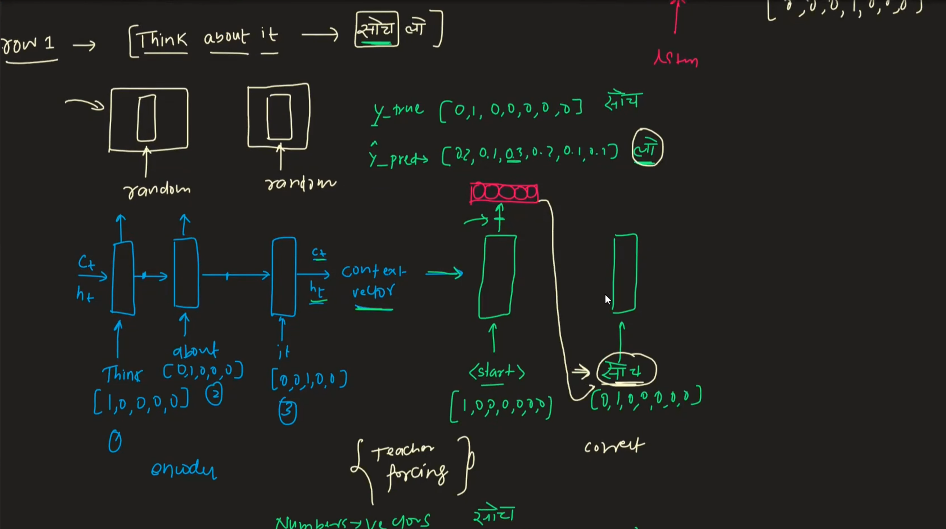

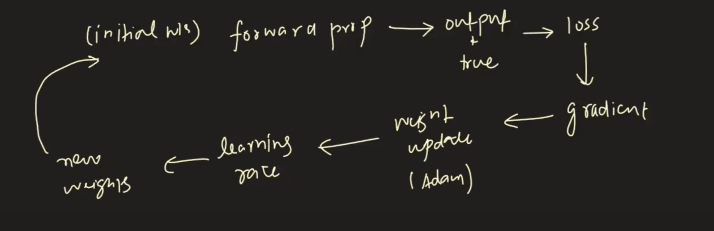

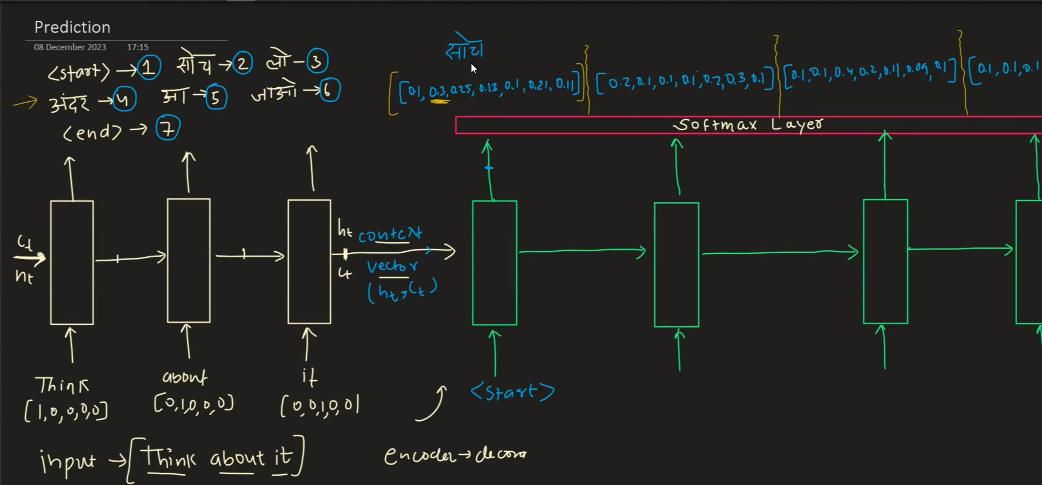

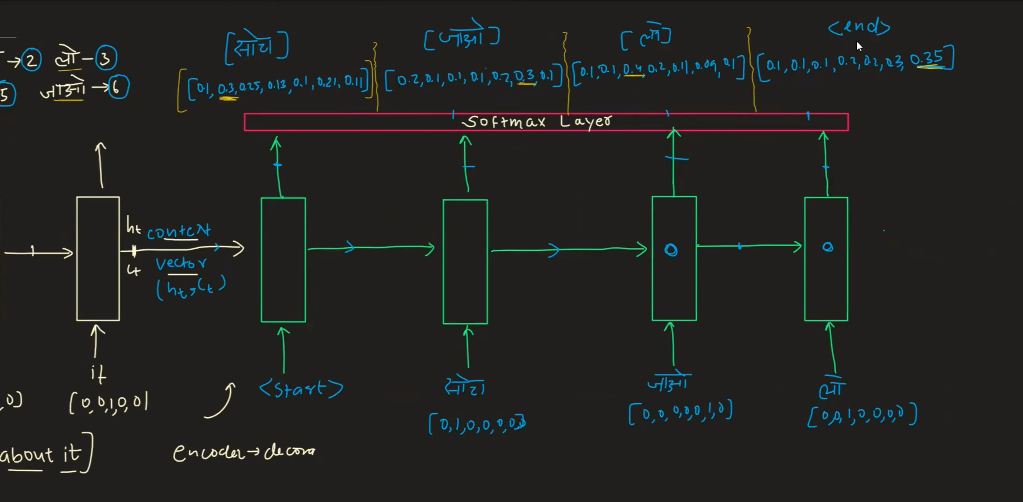

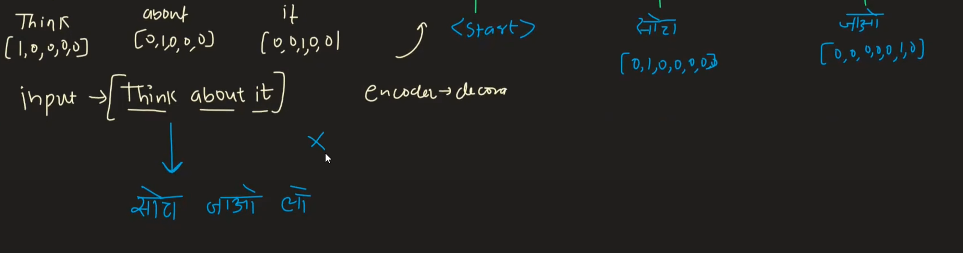

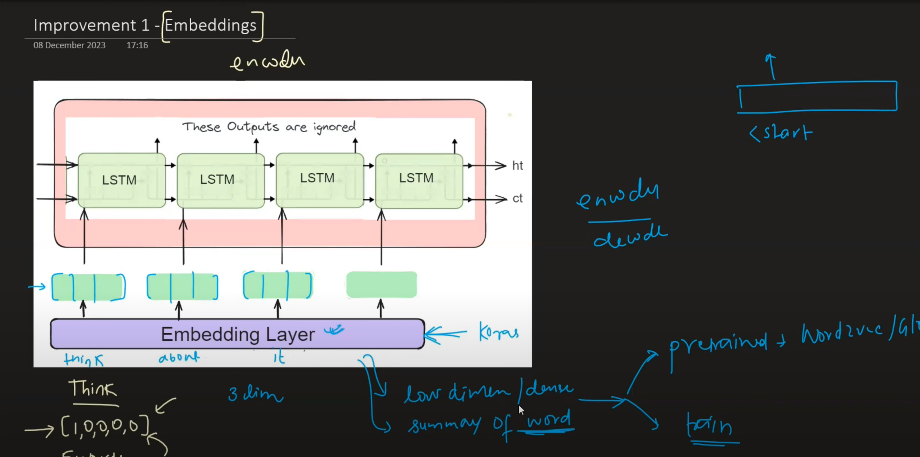

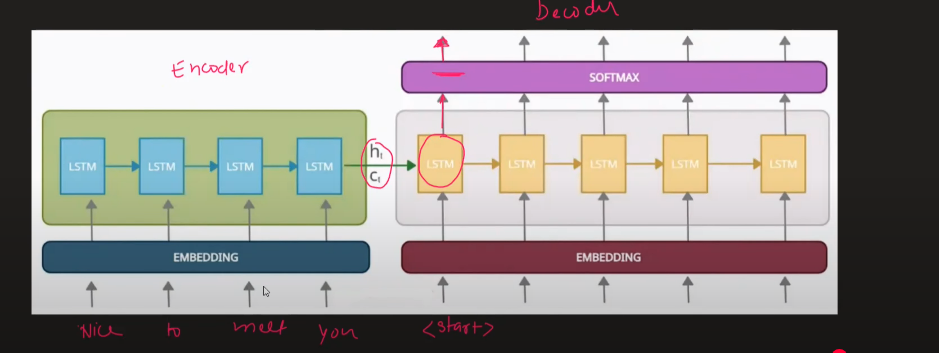

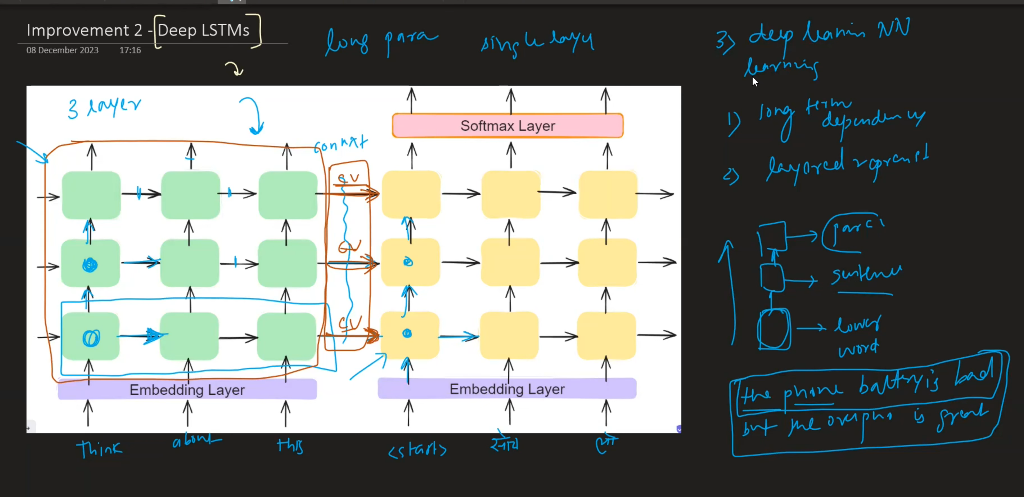

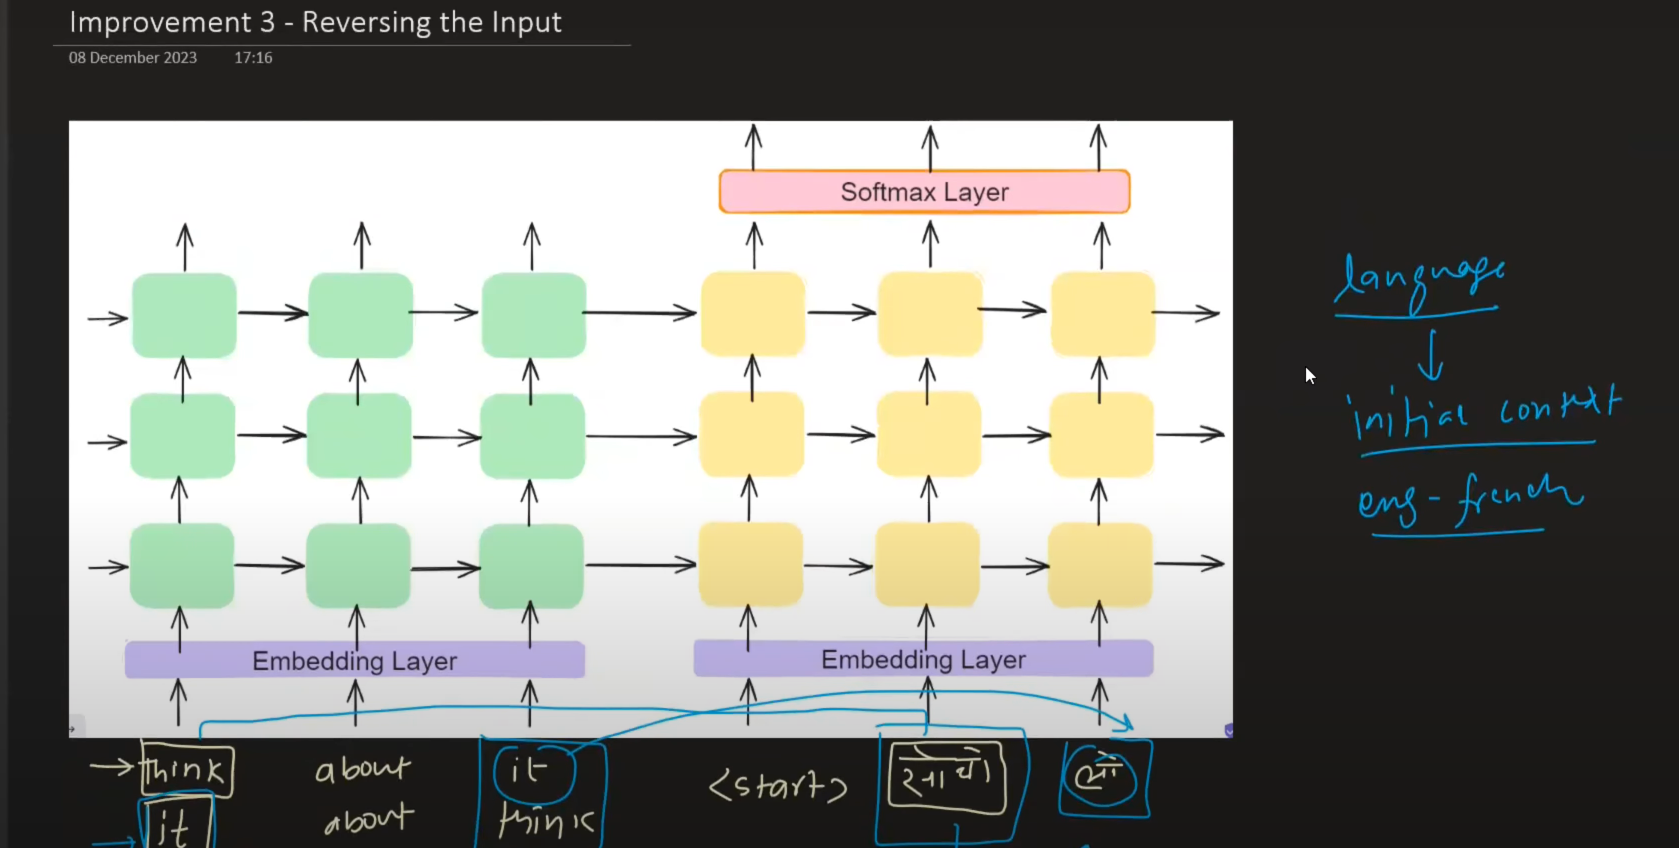

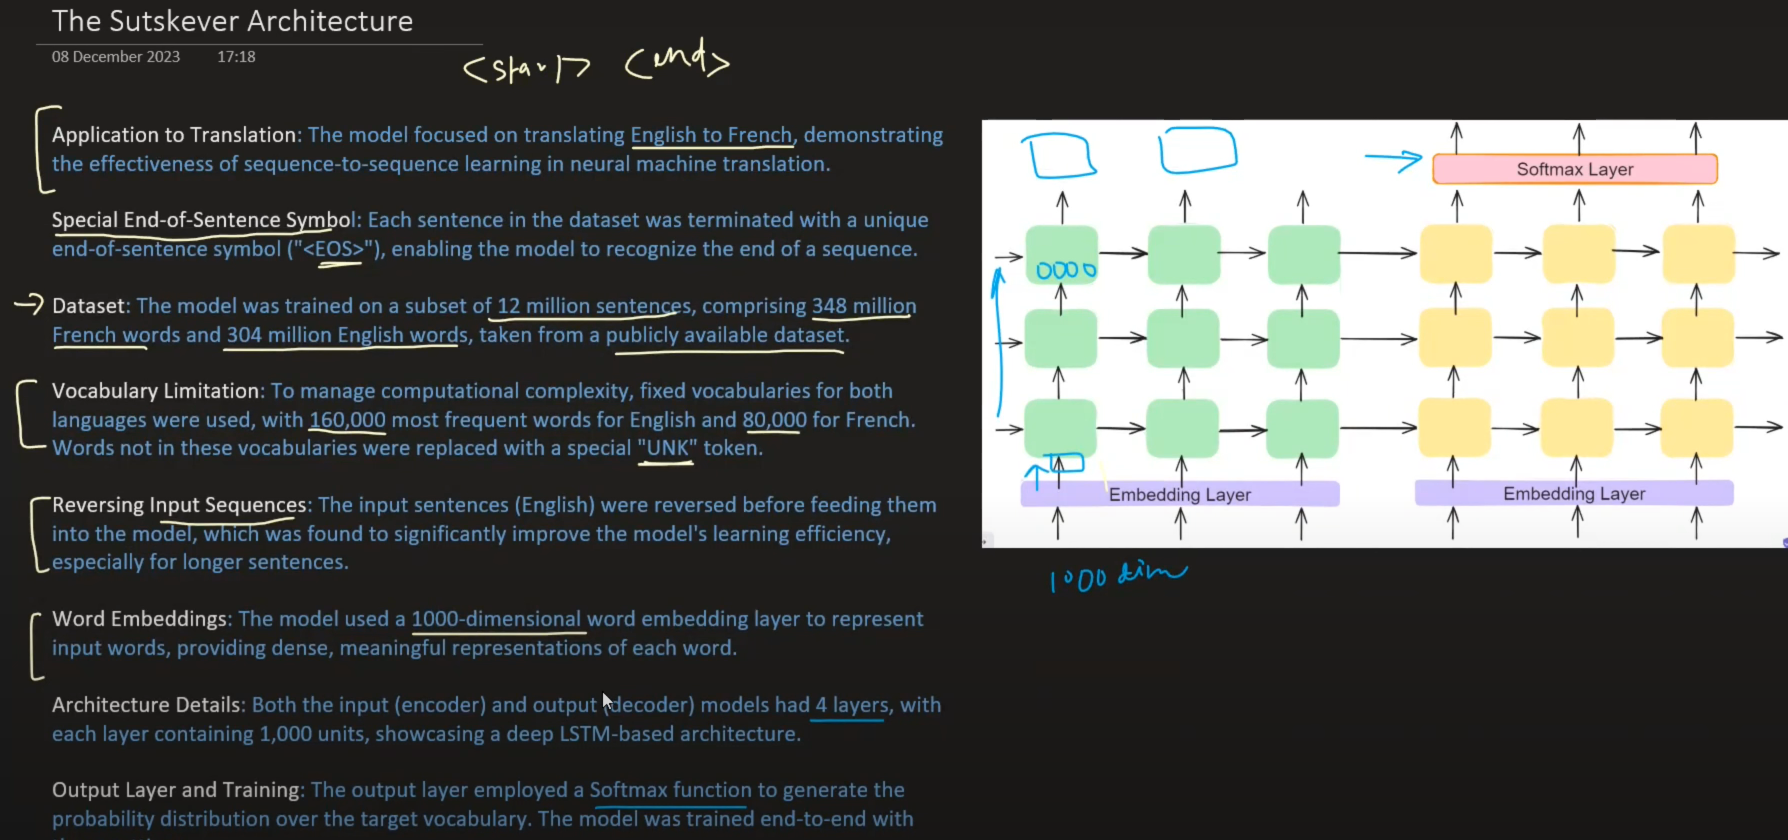

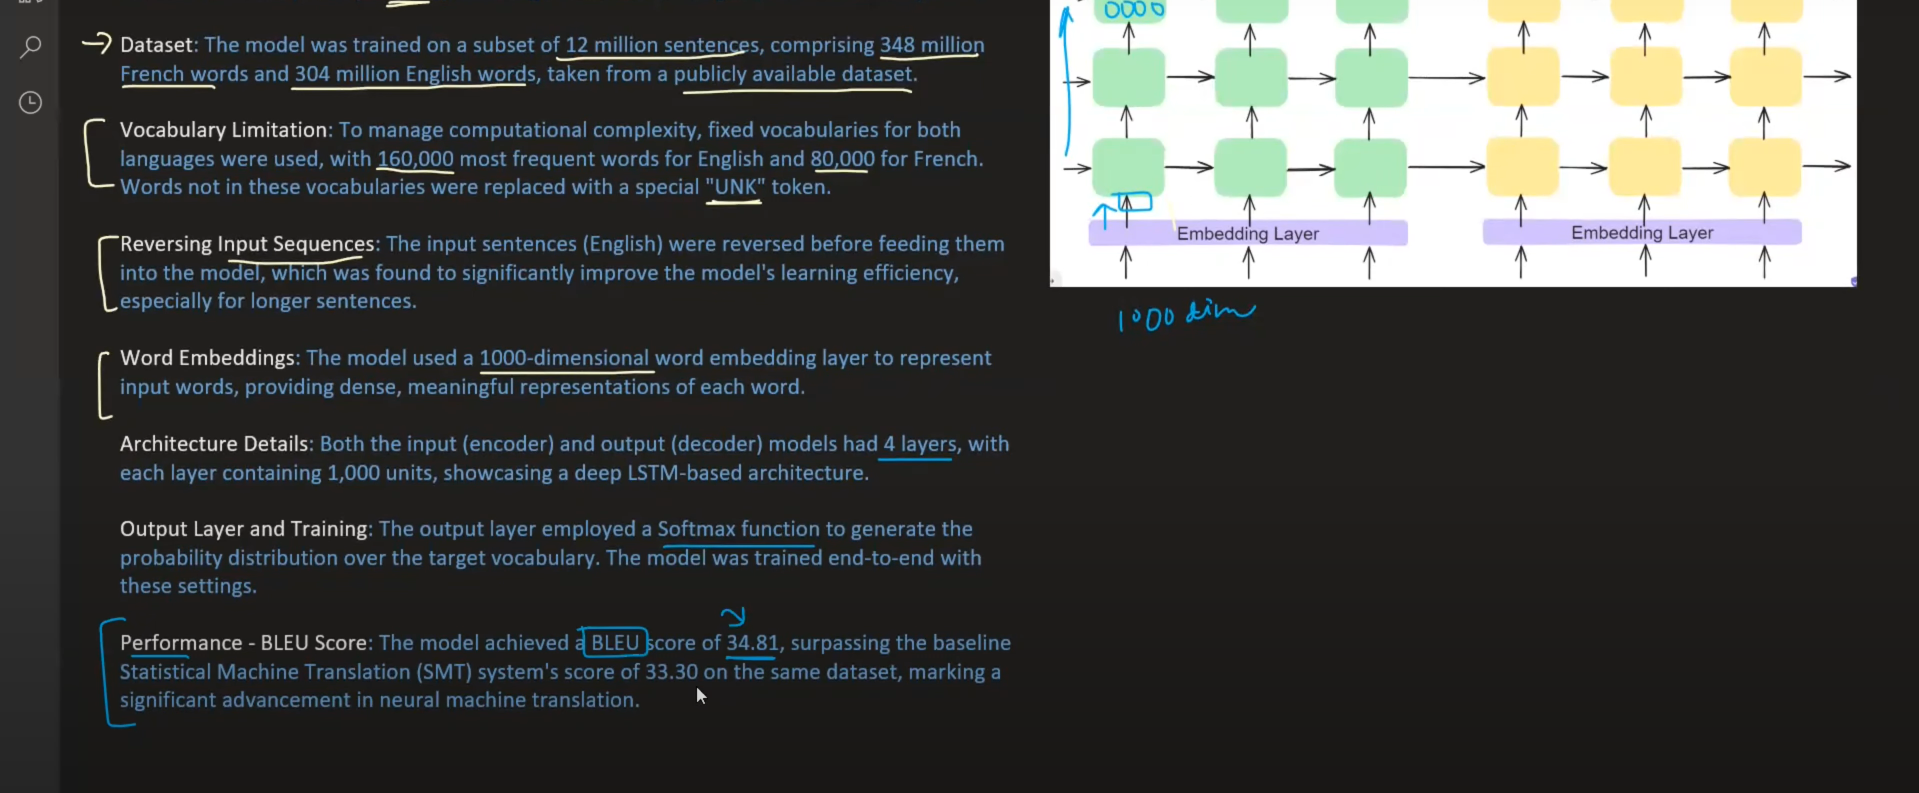

This video introduces the **Encoder-Decoder architecture**, a foundational deep learning model for **sequence-to-sequence (Seq2Seq) problems** like machine translation, which also serves as an important base for understanding advanced models like LLMs.

The journey through neural network architectures began with **Artificial Neural Networks (ANNs)** for **tabular data**, followed by **Convolutional Neural Networks (CNNs)** for **image-based data**. The third challenge involved **sequential data** like text or time series, which led to **Recurrent Neural Networks (RNNs)** and their variants, **LSTMs and GRUs**. The current challenge is **sequence-to-sequence data**, where both the input and output are sequences.

**Understanding Sequence-to-Sequence Problems:**
Seq2Seq tasks, such as English-to-Hindi machine translation, present three main challenges:
*   **Variable Input Length:** Input sentences can vary greatly in length (e.g., 2 words to 200 words).
*   **Variable Output Length:** Output sentences also have variable lengths.
*   **No Fixed Input-Output Length Relationship:** The number of words in the input does not necessarily correspond to the number of words in the output (e.g., 4 English words can translate to 6 Hindi words).
While LSTMs and GRUs can handle variable input lengths, handling variable output lengths is a new requirement for Seq2Seq problems.

**High-Level Overview of Encoder-Decoder Architecture:**
The Encoder-Decoder architecture comprises two main blocks connected by a **context vector**.
*   **Encoder:** This part of the architecture receives the input sequence (e.g., an English sentence) token by token (word by word). Its role is to understand, capture the essence, and summarize the entire input sentence into a **vector of numbers**, known as the **context vector**.
*   **Decoder:** This block receives the context vector, which is the summary of the input sentence. It then tries to understand this summary and produces the output sequence (e.g., a Hindi sentence) token by token, or word by word.

**Internal Structure of Encoder and Decoder:**
Both the Encoder and Decoder typically use **LSTMs** (Long Short-Term Memory networks), although GRUs (Gated Recurrent Units) can also be used. ANNs and CNNs are not suitable, and basic RNNs are generally avoided due to vanishing gradient problems.
*   **Encoder LSTM:** The encoder consists of an LSTM cell unrolled over time, processing the input sequence word by word. As it processes each word, it updates its **hidden states (ht) and cell states (ct)**. After processing the entire input sentence, the final hidden and cell states (ht and ct) form the **context vector**, representing the sentence's summary.
*   **Decoder LSTM:** The decoder also contains an LSTM. A key aspect is that its **initial hidden and cell states are set equal to the encoder's final hidden and cell states (the context vector)**, thereby providing the decoder with the summary of the input sequence.
    *   The decoder starts by receiving a special **"start" symbol** as input, indicating it should begin generating output.
    *   At each time step, the decoder produces a word (e.g., "आप"). This word, along with the updated internal states, is then typically fed as input to the decoder for the next time step to generate the subsequent word.
    *   This process continues until the decoder outputs a special **"end" symbol**, signaling the completion of the output sequence.
    *   To produce words, the decoder's LSTM output is passed through a **dense layer** and then a **Softmax layer**. The Softmax layer generates probabilities for each word in the output vocabulary, and the word with the highest probability is selected as the output.

**Training Process of an Encoder-Decoder Architecture:**
Training involves both the encoder and decoder simultaneously.
1.  **Dataset Preparation:** A **parallel dataset** is required, containing sentences in the source language and their corresponding translations in the target language.
2.  **Text Preprocessing:** Sentences are converted into numerical form:
    *   **Tokenization:** Sentences are broken down into individual words or sub-word units (tokens).
    *   **One-Hot Encoding:** Each unique word in the vocabulary (including "start" and "end" symbols for the target language) is represented by a unique **one-hot encoded vector**.
3.  **Forward Propagation:**
    *   An input sentence (e.g., "Think about it") is fed into the **Encoder** word by word, as one-hot encoded vectors. The encoder updates its hidden states and generates the context vector.
    *   The **Decoder** receives this context vector as its initial state. It then receives the "start" token as its first input.
    *   At each time step, the decoder's LSTM outputs are passed through a Softmax layer, which produces probability distributions over the target vocabulary. The word with the highest probability is the model's prediction.
    *   **Teacher Forcing:** A crucial technique during training is "teacher forcing". Instead of feeding the decoder's *predicted* output from the previous time step as input to the current time step (which might be incorrect, especially early in training), the **correct target word from the dataset** is used as input for the next time step. This helps accelerate training and convergence.
4.  **Loss Calculation:**
    *   After forward propagation, the model's predicted outputs (probability distributions) are compared with the true target words at each time step.
    *   Since it's a multi-class classification problem (predicting one word out of a vocabulary), **Categorical Cross-Entropy** is used as the loss function.
    *   The total loss is calculated by summing or averaging the losses from all time steps.
5.  **Backpropagation:**
    *   **Gradient Calculation:** The gradients of the total loss with respect to all trainable parameters (weights and biases of LSTMs, dense layers, Softmax) are calculated. These gradients indicate how each parameter contributed to the loss and in which direction it should be adjusted to reduce the loss.
    *   **Parameter Update:** An **optimizer** (e.g., Stochastic Gradient Descent, Adam, RMSProp) uses these gradients to adjust the parameters. A **learning rate** hyperparameter controls the speed of these adjustments.
6.  **Iteration:** This entire process (forward propagation, loss calculation, backpropagation, parameter update) is repeated for all training examples over multiple epochs, continuously updating the model's weights and biases.

**Prediction Process:**
Once the model is fully trained and its weights are finalized, the prediction process is performed:
*   **Forward Propagation Only:** Unlike training, there is no teacher forcing, backpropagation, or weight updates. The weights are "frozen".
*   The input sentence is processed by the **Encoder**, which generates the context vector.
*   The **Decoder** is initialized with this context vector and receives the "start" token.
*   The decoder predicts the first output word using the Softmax layer.
*   **The key difference from training:** The **predicted word** from the current time step is fed as input to the decoder for the next time step.
*   This sequence of prediction and feeding the predicted word back continues until the decoder outputs the "end" symbol. The concatenated predicted words form the final translated sentence.

**Improvements to the Basic Encoder-Decoder Architecture:**
The basic architecture can be significantly improved with the following techniques:
1.  **Use of Embeddings:**
    *   **Problem:** One-hot encoding creates very high-dimensional and sparse vectors for large vocabularies (e.g., 100,000 dimensions for 100,000 words), which is inefficient.
    *   **Solution:** An **embedding layer** is used to convert one-hot encoded vectors into **low-dimensional, dense representations** (e.g., a 3-dimensional vector for each word). Embeddings capture word context and meaning more effectively than one-hot encoding.
    *   Embeddings can be **pre-trained** (e.g., Word2Vec, GloVe) or **trained along with the network**. They are applied to inputs of both the Encoder and Decoder.
2.  **Deep LSTMs (Multi-Layered LSTMs):**
    *   Instead of a single LSTM layer, **multiple LSTM layers are stacked** on top of each other in both the encoder and decoder.
    *   **Benefits of Deep LSTMs:**
        *   **Better handling of long-term dependencies:** They perform better with long sentences or paragraphs as multiple layers provide increased capacity to store and summarize the sequence's context.
        *   **Layered/Hierarchical Representation Learning:** Different layers can learn different levels of abstraction. Lower layers might understand word-level features, middle layers sentence-level context, and higher layers paragraph-level context.
        *   **Increased Learning Capability:** More parameters allow the model to capture more minute variations in the data, leading to better generalization and robust handling of input variations.
    *   The original Encoder-Decoder paper used **four-layered Deep LSTMs**.
3.  **Reversing Input Sequences:**
    *   The input sequence to the encoder can be **reversed** (e.g., "It About Think" instead of "Think About It").
    *   **Benefit:** This can reduce the "distance" (in terms of processing steps) between the initial words of the input and their corresponding translations in the output, potentially making it easier for gradients to propagate and improving context capture for those initial words.
    *   This trick is not universally effective but can significantly improve translation quality for certain language pairs (like English to French, as found in the original paper) where initial words carry more contextual weight.

**Details from the Original Encoder-Decoder Paper:**
The pioneering paper on Encoder-Decoder architecture used it for **English to French machine translation**.
*   **Special Symbols:** They used an **End-Of-Sentence (EOS)** symbol.
*   **Dataset Size:** A large dataset of approximately **12 million sentences** (348 million French words, 304 million English words) was used for training.
*   **Vocabulary Size:** The input (English) vocabulary had 160,000 words, and the target (French) vocabulary had 80,000 words. Out-of-vocabulary words were represented by a special **UNK (unknown) token**.
*   **Improvements Applied:** They employed **reversing input sequences**, **1000-dimensional word embeddings**, and a **four-layered Deep LSTM** architecture with 1000 units per LSTM layer.
*   **Performance:** The model achieved a **BLEU score of 34.8**, which surpassed the performance of baseline statistical models at the time, leading to its significant recognition.



*   **Introduction of Sequence-to-Sequence (Seq2Seq) Problem:**
    *   Deep Neural Networks (DNNs) are powerful models but traditionally struggle with **mapping sequences to sequences** where input and output lengths are not fixed in advance. Problems like speech recognition, machine translation, and question answering are inherently sequential.
    *   While earlier networks like ANNs handled tabular data and CNNs excelled with image data, **Recurrent Neural Networks (RNNs)** and their variants (LSTMs, GRUs) were developed for sequential data with variable input lengths [conversation history]. However, handling variable output lengths simultaneously was a new challenge for general Seq2Seq problems [conversation history].

*   **The Encoder-Decoder Architecture Emerges (Core Idea):**
    *   A general **end-to-end approach to sequence learning** was presented, making minimal assumptions about sequence structure.
    *   The core idea is to use **one LSTM to read the input sequence** (token by token) to obtain a **fixed-dimensional vector representation** (the **context vector**), and then use **another deep LSTM to decode the target sequence** from this vector [2, 7, 8, 14, conversation history].
    *   This approach was pioneered by mapping the entire input sentence to a vector and then back to a sentence.
    *   LSTMs were chosen due to their ability to successfully learn on data with **long-range temporal dependencies**, which is critical given the considerable time lag between inputs and corresponding outputs in Seq2Seq tasks.

*   **Architectural Details and Enhancements (as presented in the source paper):**
    *   The model typically reads an input sentence and produces an output sentence, stopping predictions after outputting an **end-of-sentence (EOS) token**.
    *   For the described English-to-French translation task, the model used **two different LSTMs**: one for the input (encoder) and one for the output (decoder), which increases model parameters and allows for training on multiple language pairs.
    *   **Deep LSTMs significantly outperformed shallow LSTMs**, so an architecture with **four LSTM layers** was chosen. Each layer had 1000 cells, and 1000-dimensional word embeddings were used.
    *   The final hidden state of the encoder LSTM provides the fixed-dimensional representation of the input sequence, and this representation serves as the initial hidden state for the decoder LSTM [17, 18, conversation history].
    *   **Word embeddings** are used to represent words in a low-dimensional, dense space, which is more efficient and semantically rich than one-hot encoding [conversation history].
    *   A **naive Softmax layer** over the target vocabulary (e.g., 80,000 words) is used at each output step of the decoder to predict the next word [18, 29, conversation history].

*   **Key Experimental Setup and Findings from the Paper (WMT'14 English to French MT Task):**
    *   **Dataset:** The models were trained on a subset of the **WMT'14 English to French dataset**, consisting of approximately **12 million sentences** (348M French words, 304M English words).
    *   **Vocabulary:** A fixed vocabulary of **160,000 most frequent English words** for the source and **80,000 most frequent French words** for the target was used. Out-of-vocabulary words were replaced with a special **"UNK" token**.
    *   **Reversing Source Sentences:** A crucial finding was that **reversing the order of words in the input (source) sentences** (but not the target sentences) **markedly improved the LSTM’s performance**. This simple data transformation significantly reduced the "minimal time lag" between corresponding words, making the optimization problem easier for Stochastic Gradient Descent (SGD) and improving gradient propagation.
    *   **Training Process:** The models were trained by maximizing the log probability of a correct translation given the source sentence. Training involved **stochastic gradient descent** with a fixed learning rate that was halved after 5 epochs. **Gradient clipping** was applied to prevent exploding gradients. Batches of roughly similar sentence lengths were used for a 2x speedup.
    *   **Decoding:** During translation, a simple **left-to-right beam search decoder** was used to find the most likely translation.
    *   **Performance on Translation:** The ensemble of 5 deep LSTMs achieved a **BLEU score of 34.8** on the WMT'14 English to French test set, outperforming a phrase-based Statistical Machine Translation (SMT) baseline which scored 33.3. This was the first time a pure neural translation system achieved such a result on a large-scale MT task.
    *   **Performance on Long Sentences:** Surprisingly, the LSTM **did not suffer on very long sentences**, contrary to experiences reported by other researchers with related architectures. LSTMs trained on reversed source sentences showed better memory utilization and performed well on long sentences.
    *   **Sentence Representations:** The LSTM learned **sensible phrase and sentence representations** that are sensitive to word order and relatively invariant to active/passive voice.
    *   **Rescoring SMT Output:** When used to **rescore the 1000-best hypotheses** produced by the SMT baseline, the LSTM's BLEU score further increased to **36.5**, getting close to the previous best published result for the task.
    *   **Parallelization:** To speed up training, the model was parallelized using an 8-GPU machine, with each LSTM layer on a different GPU and the remaining GPUs for Softmax parallelization, achieving 6,300 words per second.

*   **Conclusion:**
    *   The work demonstrated that a large deep LSTM, with a limited vocabulary and minimal assumptions about problem structure, can **outperform a standard SMT-based system** on a large-scale MT task.
    *   The significant improvement from **reversing source sentences** highlights the importance of finding problem encodings that introduce more short-term dependencies to simplify the learning problem.
    *   The ability to correctly translate very long sentences was a surprising and important finding. These results suggest the approach is promising for **other challenging sequence-to-sequence problems**.